# Employee Attrition Analysis — End-to-End
**Portfolio pembelajaran Data Analyst | Python · SQL · Visualisasi · ML ringan**

Notebook ini melanjutkan `01_Data_Understanding_Employee_Attrition.ipynb`: pemeriksaan ukuran, missing values, duplikat, target, dan kolom konstan dipertahankan serta dirapikan menjadi alur lengkap.

**Cara menggunakan di Google Colab:** upload notebook lewat **File → Upload notebook**, pilih runtime Python, lalu **Runtime → Run all**. Pada langkah input, upload CSV asli atau ZIP yang berisi CSV. Opsi Google Drive tersedia pada cell yang sama. Grafik dan hasil tersimpan adalah hasil validasi; menjalankan ulang akan menghitung semuanya dari input Anda.

**Daftar isi:** 01 Business Understanding → 02 Setup & Input → 03 Data Understanding → 04 Cleaning → 05 EDA → 06 SQL → 07 Insights & Recommendations → 08 ML & Evaluation → 09 Limitations & Conclusion → 10 GitHub & Export.

Sumber utama: [IBM HR Analytics Employee Attrition & Performance di Kaggle](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset). Data ini **fiktif**, dibuat untuk latihan; bukan catatan tenaga kerja IBM yang sebenarnya. Salinan publik untuk validasi: [repository dataset](https://github.com/b1gvini/ibm-hr-analytics-attrition-dataset). Semua temuan menunjukkan **asosiasi**, bukan sebab-akibat.

## 01 — Business Understanding
**Pertanyaan bisnis:** bagaimana proporsi attrition dalam sampel, segmen pekerjaan mana yang memiliki proporsi lebih tinggi, dan hipotesis retensi apa yang layak diteliti lebih lanjut?

Pemangku kepentingan: HR analyst, HR business partner, dan manajer. Output utama adalah analisis tingkat segmen, bukan penilaian individu.

**KPI:** jumlah observasi, jumlah `Attrition = Yes`, dan **proporsi attrition = jumlah Yes / jumlah observasi × 100%**. Tidak ada tanggal keluar atau periode pengamatan, sehingga KPI ini **bukan annual turnover rate**. Bandingkan proporsi serta ukuran kelompok; jumlah resign yang besar bisa sekadar mencerminkan kelompok yang besar.

ML adalah pelengkap pembelajaran klasifikasi. Keberhasilan teknis diukur dengan average precision, precision, recall, F1, ROC-AUC, serta confusion matrix dibanding baseline. Keberhasilan bisnis belum dapat diukur: dataset tidak mencatat biaya, intervensi, atau hasil program retensi.

## 02 — Setup & Input Data
Library di bawah umumnya sudah tersedia di Colab. Jika import gagal, jalankan cell terpisah `%pip install pandas numpy matplotlib seaborn scikit-learn` lalu ulangi import. SQLite merupakan library bawaan Python.

In [1]:
import os, io, json, zipfile, sqlite3, hashlib, platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    fbeta_score, roc_auc_score, average_precision_score, ConfusionMatrixDisplay,
    PrecisionRecallDisplay, RocCurveDisplay, classification_report)
from sklearn.inspection import permutation_importance
SEED = 42
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.figsize': (9, 4.5), 'figure.dpi': 120})
pd.set_option('display.max_columns', 40)
OUTPUT_DIR = Path('employee_attrition_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
versions = {'python': platform.python_version(), 'pandas': pd.__version__,
            'numpy': np.__version__, 'sklearn': sklearn.__version__}
print(versions)

{'python': '3.12.14', 'pandas': '3.0.6', 'numpy': '2.5.3', 'sklearn': '1.9.1'}


### Pilih sumber input
Default `INPUT_MODE = "upload"`: pilih **satu** CSV atau ZIP berisi **satu** CSV. ZIP dibaca langsung tanpa ekstraksi ke filesystem.

Untuk Drive, ubah menjadi `"drive"` dan isi `DRIVE_CSV` dengan lokasi CSV Anda; notebook akan meminta mount Drive. Untuk Jupyter biasa, gunakan `"local"` dan isi path relatif `LOCAL_CSV`. Tidak ada ketergantungan pada `/mnt/data` atau path komputer pembuat notebook. Variabel lingkungan `ATTRITION_CSV` hanya menjadi override untuk validasi otomatis.

In [2]:
INPUT_MODE = 'upload'  # upload | drive | local
DRIVE_CSV = '/content/drive/MyDrive/employee-attrition/WA_Fn-UseC_-HR-Employee-Attrition.csv'
LOCAL_CSV = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
override = os.environ.get('ATTRITION_CSV')
if override:
    raw_bytes = Path(override).read_bytes()
    source_name = Path(override).name
elif INPUT_MODE == 'upload':
    from google.colab import files
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError('Upload tepat satu CSV atau ZIP.')
    source_name, raw_bytes = next(iter(uploaded.items()))
elif INPUT_MODE == 'drive':
    from google.colab import drive
    drive.mount('/content/drive')
    source_name = Path(DRIVE_CSV).name
    raw_bytes = Path(DRIVE_CSV).read_bytes()
elif INPUT_MODE == 'local':
    source_name = Path(LOCAL_CSV).name
    raw_bytes = Path(LOCAL_CSV).read_bytes()
else:
    raise ValueError('INPUT_MODE harus upload, drive, atau local.')
if source_name.lower().endswith('.zip'):
    with zipfile.ZipFile(io.BytesIO(raw_bytes)) as archive:
        candidates = [n for n in archive.namelist() if n.lower().endswith('.csv') and not n.startswith('__MACOSX/')]
        if len(candidates) != 1:
            raise ValueError(f'ZIP harus berisi satu CSV; ditemukan: {candidates}')
        raw_bytes = archive.read(candidates[0])
        source_name = Path(candidates[0]).name
data_hash = hashlib.sha256(raw_bytes).hexdigest()
df = pd.read_csv(io.BytesIO(raw_bytes))
print('Sumber:', source_name, '\nSHA256:', data_hash)
display(df.head())

Sumber: WA_Fn-UseC_-HR-Employee-Attrition.csv 
SHA256: a5c31e38bd7fafc9bc333884eb181b06b41b8e5e488e8f7ccb27199fb3be7659


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 03 — Data Understanding
Satu baris mewakili satu observasi karyawan. Versi acuan memiliki **1.470 baris × 35 kolom**. Pemeriksaan schema menghentikan analisis jika file yang diupload berbeda, agar hasil tidak diam-diam menggunakan data lain.

In [3]:
expected_columns = ['Age','Attrition','BusinessTravel','DailyRate','Department','DistanceFromHome',
 'Education','EducationField','EmployeeCount','EmployeeNumber','EnvironmentSatisfaction','Gender',
 'HourlyRate','JobInvolvement','JobLevel','JobRole','JobSatisfaction','MaritalStatus','MonthlyIncome',
 'MonthlyRate','NumCompaniesWorked','Over18','OverTime','PercentSalaryHike','PerformanceRating',
 'RelationshipSatisfaction','StandardHours','StockOptionLevel','TotalWorkingYears',
 'TrainingTimesLastYear','WorkLifeBalance','YearsAtCompany','YearsInCurrentRole',
 'YearsSinceLastPromotion','YearsWithCurrManager']
assert df.shape == (1470, 35), f'Ukuran tidak sesuai versi acuan: {df.shape}'
assert set(df.columns) == set(expected_columns), 'Schema berbeda dari IBM HR versi acuan.'
df.info()
overview = pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing': df.isna().sum(),
                        'unique': df.nunique(dropna=False)})
display(overview)
print('Duplikat seluruh baris:', df.duplicated().sum())
display(df.describe().T.round(2))

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

,dtype,missing,unique
Age,int64,0,43
Attrition,str,0,2
BusinessTravel,str,0,3
DailyRate,int64,0,886
Department,str,0,3
DistanceFromHome,int64,0,29
Education,int64,0,5
EducationField,str,0,6
EmployeeCount,int64,0,1
EmployeeNumber,int64,0,1470


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.92,9.14,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.49,403.51,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.19,8.11,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.91,1.02,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.00,0.00,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.87,602.02,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.72,1.09,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.89,20.33,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.73,0.71,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.06,1.11,1.0,1.00,2.0,3.00,5.0


### Kamus variabel dan jenis data
| Kelompok | Kolom | Cara membaca |
|---|---|---|
| Target | Attrition | Yes = keluar; No = tidak keluar pada label dataset |
| Demografi | Age, Gender, MaritalStatus | Usia dan kategori demografi; bukan dasar keputusan individual |
| Pendidikan | Education, EducationField | Jenjang ordinal dan bidang nominal |
| Pekerjaan | Department, JobRole, JobLevel, BusinessTravel, OverTime | Departemen, peran, jenjang, perjalanan, status lembur |
| Kondisi | DistanceFromHome | Jarak; satuan tidak dipastikan di notebook |
| Kompensasi | MonthlyIncome, DailyRate, HourlyRate, MonthlyRate, PercentSalaryHike, StockOptionLevel | Income/rate tidak diasumsikan bermata uang tertentu; rate tidak dianggap saling ekuivalen |
| Kepuasan | EnvironmentSatisfaction, JobSatisfaction, RelationshipSatisfaction | 1 Low, 2 Medium, 3 High, 4 Very High |
| Engagement | JobInvolvement, WorkLifeBalance | Involvement: 1 Low–4 Very High; balance: 1 Bad, 2 Good, 3 Better, 4 Best |
| Kinerja | PerformanceRating | 1 Low, 2 Good, 3 Excellent, 4 Outstanding; cek nilai yang benar-benar muncul |
| Pengalaman | TotalWorkingYears, NumCompaniesWorked | Lama karier dan jumlah perusahaan |
| Masa kerja | YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager | Durasi dalam tahun |
| Pengembangan | TrainingTimesLastYear | Jumlah pelatihan tahun terakhir |
| Administratif | EmployeeNumber, EmployeeCount, Over18, StandardHours | ID dan kolom konstan; dibuang dari analisis/model |

`Education`: 1 Below College, 2 College, 3 Bachelor, 4 Master, 5 Doctor. `JobLevel` dan `StockOptionLevel` juga merupakan jenjang/kategori. Angka ordinal menyatakan urutan, bukan jarak yang pasti setara: skor kepuasan 4 tidak berarti dua kali skor 2.

## 04 — Data Cleaning & Quality Checks
Buat salinan raw. Rapikan whitespace pada teks, periksa target, missing, ID, rentang ordinal, dan konsistensi durasi. Jangan menghapus outlier pendapatan/masa kerja hanya karena nilainya tinggi: nilai ekstrem dapat valid. Jangan menghapus profil identik setelah ID dibuang karena mereka dapat mewakili orang yang berbeda.

Versi acuan tidak memerlukan imputasi atau penghapusan baris. Jika ada missing/duplikat pada input, hentikan dan investigasi. Imputer tetap dipasang dalam pipeline ML sebagai contoh penanganan input baru, dan hanya dipelajari dari data training.

In [4]:
df_clean = df.copy(deep=True)
text_cols = df_clean.select_dtypes(include=['object', 'string']).columns
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()
assert set(df_clean['Attrition'].unique()) == {'Yes', 'No'}
assert df_clean.isna().sum().sum() == 0, 'Investigasi missing sebelum lanjut.'
assert not df_clean.duplicated().any(), 'Investigasi duplikat sebelum lanjut.'
assert df_clean['EmployeeNumber'].is_unique, 'ID karyawan tidak unik.'
constant_columns = [c for c in df_clean if df_clean[c].nunique() == 1]
assert set(constant_columns) == {'EmployeeCount','Over18','StandardHours'}
ordinal_ranges = {'Education': (1,5), 'EnvironmentSatisfaction': (1,4),
 'JobSatisfaction': (1,4), 'RelationshipSatisfaction': (1,4), 'JobInvolvement': (1,4),
 'WorkLifeBalance': (1,4), 'PerformanceRating': (1,4), 'JobLevel': (1,5), 'StockOptionLevel': (0,3)}
for col, (low, high) in ordinal_ranges.items():
    assert df_clean[col].between(low, high).all(), f'Nilai tidak valid: {col}'
assert (df_clean.select_dtypes(include='number') >= 0).all().all()
duration_flags = pd.DataFrame({
 'company_gt_career': df_clean.YearsAtCompany > df_clean.TotalWorkingYears,
 'role_gt_company': df_clean.YearsInCurrentRole > df_clean.YearsAtCompany,
 'promotion_gt_company': df_clean.YearsSinceLastPromotion > df_clean.YearsAtCompany,
 'manager_gt_company': df_clean.YearsWithCurrManager > df_clean.YearsAtCompany})
display(duration_flags.sum().rename('flag_count').to_frame())
assert not duration_flags.any().any(), 'Investigasi konsistensi durasi.'
drop_columns = ['EmployeeCount','Over18','StandardHours','EmployeeNumber']
df_clean = df_clean.drop(columns=drop_columns)
assert df_clean.shape == (1470,31)
assert df.shape == (1470,35), 'Raw harus tetap utuh.'
cleaning_log = pd.DataFrame({'langkah': ['Raw','Drop 3 constant + 1 ID','Final'],
                            'rows': [len(df)]*3, 'columns': [35,31,31]})
display(cleaning_log)

,flag_count
company_gt_career,0
role_gt_company,0
promotion_gt_company,0
manager_gt_company,0


,langkah,rows,columns
0,Raw,1470,35
1,Drop 3 constant + 1 ID,1470,31
2,Final,1470,31


**Interpretasi cleaning:** empat kolom dibuang karena tidak memberi variasi atau hanya mengidentifikasi observasi. Target masih berupa Yes/No di cleaned CSV agar mudah dibaca. Kolom bantu EDA disimpan terpisah, sehingga cleaned CSV tetap berisi 31 kolom asli yang dipertahankan.

## 05 — Exploratory Data Analysis (EDA)
### 05.1 Proporsi attrition dan ketidakseimbangan kelas
Kita mulai dari denominator keseluruhan. Grafik count melengkapi KPI; kelas mayoritas penting ketika membaca akurasi model.

,count,percent
Attrition,,
No,1233,83.88
Yes,237,16.12


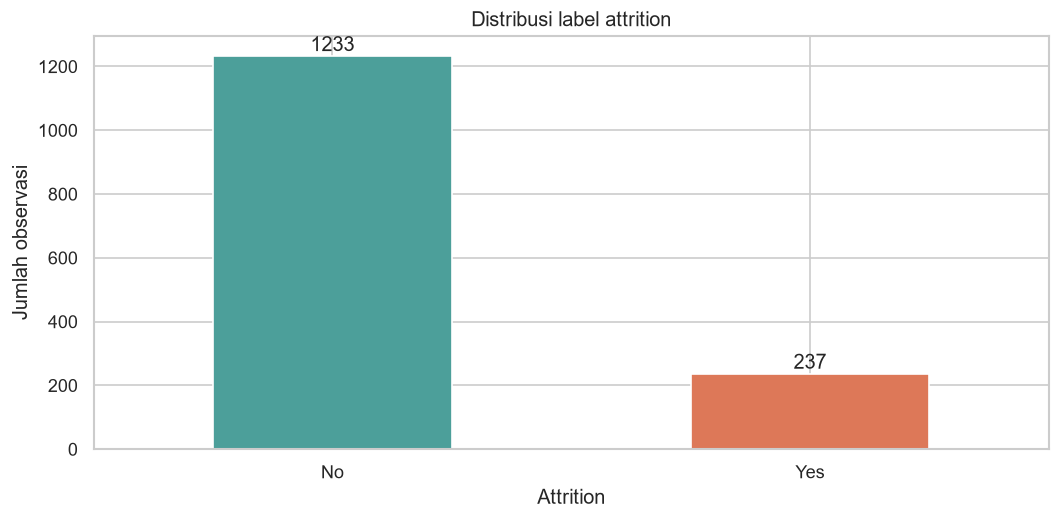

**Hasil:** 237 dari 1,470 observasi berlabel Yes (**16.12%**). Selalu menebak No memberi akurasi 83.88%, tetapi recall Yes = 0.

In [5]:
eda = df_clean.copy()
eda['AttritionFlag'] = eda.Attrition.map({'No':0,'Yes':1})
counts = eda.Attrition.value_counts().reindex(['No','Yes'])
overall = eda.AttritionFlag.mean()
display(pd.DataFrame({'count': counts, 'percent': counts / len(eda) * 100}).round(2))
ax = counts.plot.bar(color=['#4c9f9a','#dd7858'], rot=0)
ax.set(title='Distribusi label attrition', xlabel='Attrition', ylabel='Jumlah observasi')
for i, val in enumerate(counts): ax.text(i, val+15, str(val), ha='center')
plt.tight_layout(); plt.show()
display(Markdown(f'**Hasil:** {counts["Yes"]:,} dari {len(eda):,} observasi berlabel Yes (**{overall:.2%}**). Selalu menebak No memberi akurasi {(1-overall):.2%}, tetapi recall Yes = 0.'))

### 05.2 Segmen pekerjaan, lembur, dan kepuasan
Tabel selalu menampilkan ukuran kelompok, jumlah Yes, proporsi, dan selisih **poin persentase (pp)** dari keseluruhan. Interval Wilson 95% membantu menunjukkan ketidakpastian kelompok kecil, tetapi mengasumsikan observasi independen dan tidak menjadikan data fiktif representatif.

**OverTime**

,n,exits,rate_pct,difference_pp,ci_low_pct,ci_high_pct
OverTime,,,,,,
Yes,416,127,30.53,14.41,26.30,35.12
No,1054,110,10.44,-5.69,8.73,12.43


**Department**

,n,exits,rate_pct,difference_pp,ci_low_pct,ci_high_pct
Department,,,,,,
Sales,446,92,20.63,4.51,17.13,24.63
Human Resources,63,12,19.05,2.93,11.25,30.41
Research & Development,961,133,13.84,-2.28,11.80,16.17


**JobRole**

...

,n,exits,rate_pct,difference_pp,ci_low_pct,ci_high_pct
BusinessTravel,,,,,,
Travel_Frequently,277,69,24.91,8.79,20.18,30.32
Travel_Rarely,1043,156,14.96,-1.17,12.92,17.25
Non-Travel,150,12,8.00,-8.12,4.64,13.46


**JobSatisfaction**

,n,exits,rate_pct,difference_pp,ci_low_pct,ci_high_pct
JobSatisfaction,,,,,,
1,289,66,22.84,6.71,18.37,28.01
3,442,73,16.52,0.39,13.35,20.26
2,280,46,16.43,0.31,12.55,21.22
4,459,52,11.33,-4.79,8.74,14.56


**WorkLifeBalance**

,n,exits,rate_pct,difference_pp,ci_low_pct,ci_high_pct
WorkLifeBalance,,,,,,
1,80,25,31.25,15.13,22.15,42.07
4,153,27,17.65,1.52,12.42,24.46
2,344,58,16.86,0.74,13.27,21.18
3,893,127,14.22,-1.90,12.08,16.67


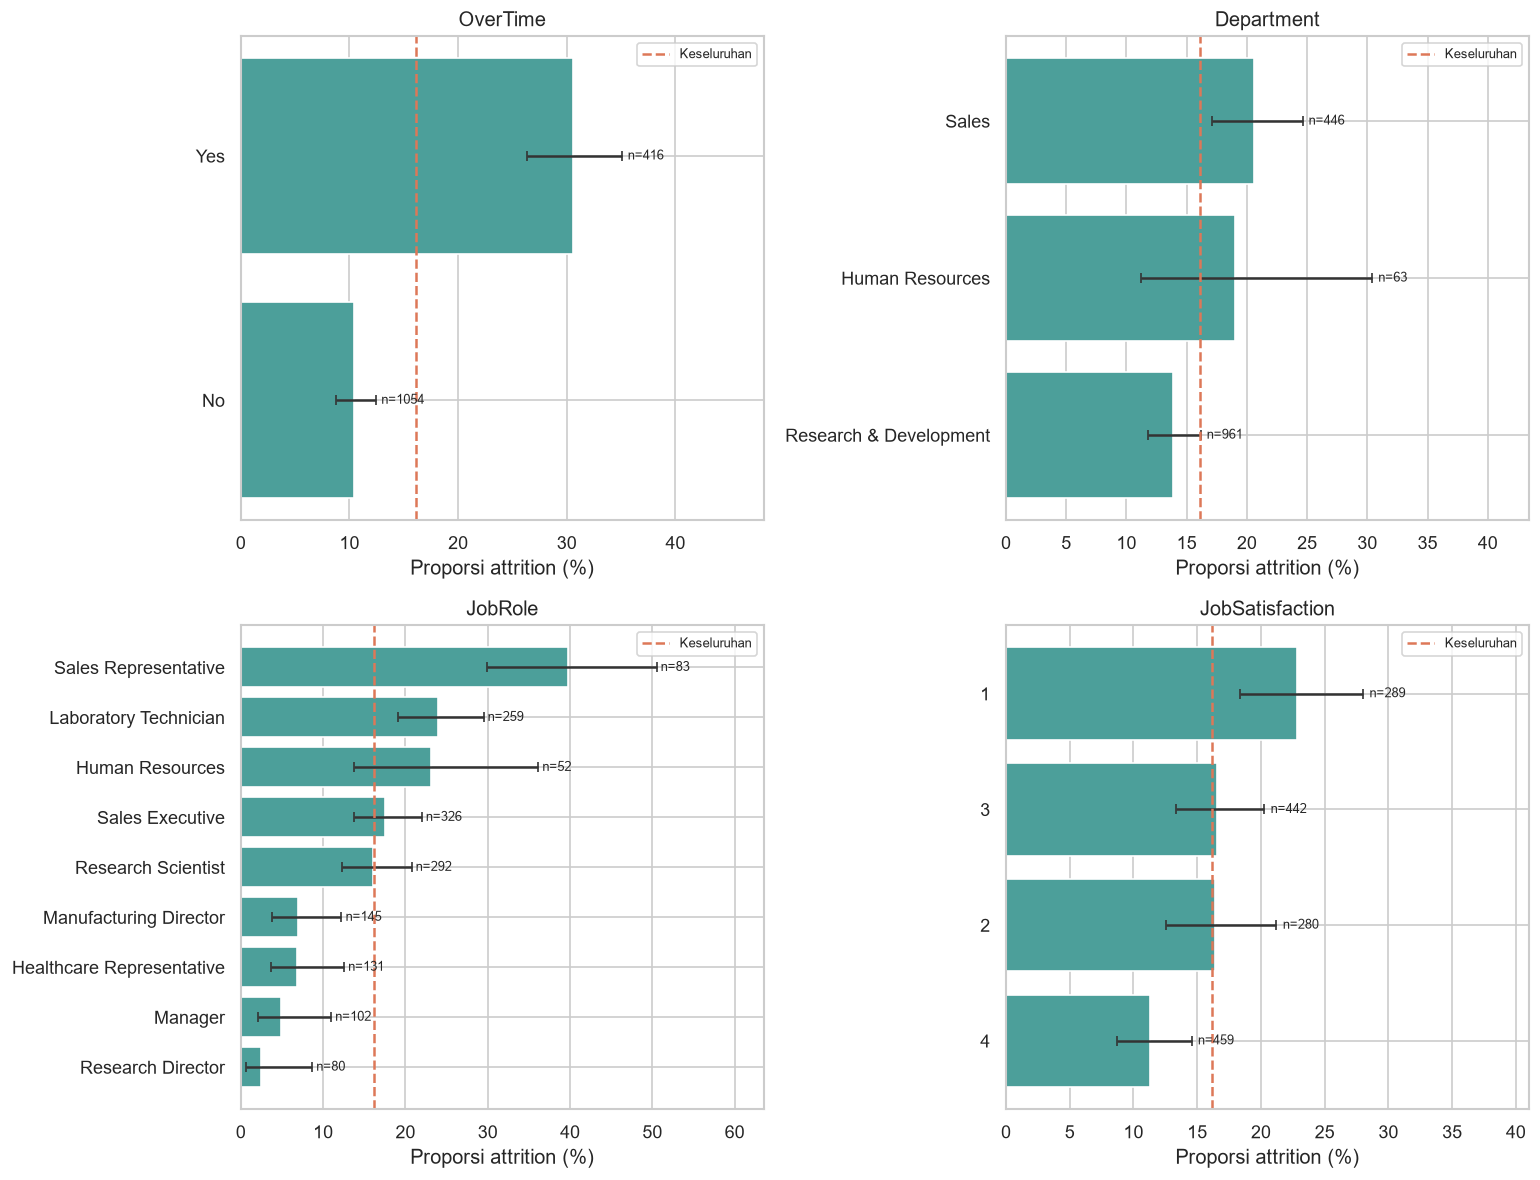

In [6]:
def segment_table(column):
    tab = eda.groupby(column, observed=True)['AttritionFlag'].agg(n='size', exits='sum')
    p = tab.exits / tab.n
    z = 1.96
    center = (p + z*z/(2*tab.n)) / (1 + z*z/tab.n)
    half = z*np.sqrt(p*(1-p)/tab.n + z*z/(4*tab.n**2)) / (1+z*z/tab.n)
    tab['rate_pct'] = 100*p
    tab['difference_pp'] = 100*(p-overall)
    tab['ci_low_pct'], tab['ci_high_pct'] = 100*(center-half), 100*(center+half)
    return tab.sort_values('rate_pct', ascending=False)

segments = {c: segment_table(c) for c in ['OverTime','Department','JobRole','BusinessTravel',
                                          'JobSatisfaction','WorkLifeBalance']}
for col, tab in segments.items():
    display(Markdown(f'**{col}**')); display(tab.round(2))
fig, axes = plt.subplots(2,2,figsize=(13,10))
for ax, col in zip(axes.flat, ['OverTime','Department','JobRole','JobSatisfaction']):
    tab = segments[col].sort_values('rate_pct')
    ax.barh(tab.index.astype(str), tab.rate_pct, color='#4c9f9a')
    ax.errorbar(tab.rate_pct, np.arange(len(tab)),
                xerr=[tab.rate_pct-tab.ci_low_pct,tab.ci_high_pct-tab.rate_pct],
                fmt='none',ecolor='#333333',capsize=3)
    ax.axvline(overall*100,color='#dd7858',linestyle='--',label='Keseluruhan')
    for i, (_, row) in enumerate(tab.iterrows()):
        ax.text(row.ci_high_pct+0.5,i,f'n={int(row.n)}',va='center',fontsize=8)
    ax.set(title=col, xlabel='Proporsi attrition (%)', xlim=(0, max(tab.ci_high_pct)+13))
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 05.3 Usia, income, dan masa kerja
Boxplot membandingkan distribusi serta median. Outlier ditampilkan, bukan otomatis dibuang. Bucket masa kerja ditentukan sebelum melihat proporsi; batas interval dijelaskan agar pengelompokan dapat diulang.

Age        MonthlyIncome          YearsAtCompany        \
          median   mean        median     mean         median  mean   
Attrition                                                             
No          36.0  37.56        5204.0  6832.74            6.0  7.37   
Yes         32.0  33.61        3202.0  4787.09            3.0  5.13   

          DistanceFromHome         
                    median   mean  
Attrition                          
No                     7.0   8.92  
Yes                    9.0  10.63

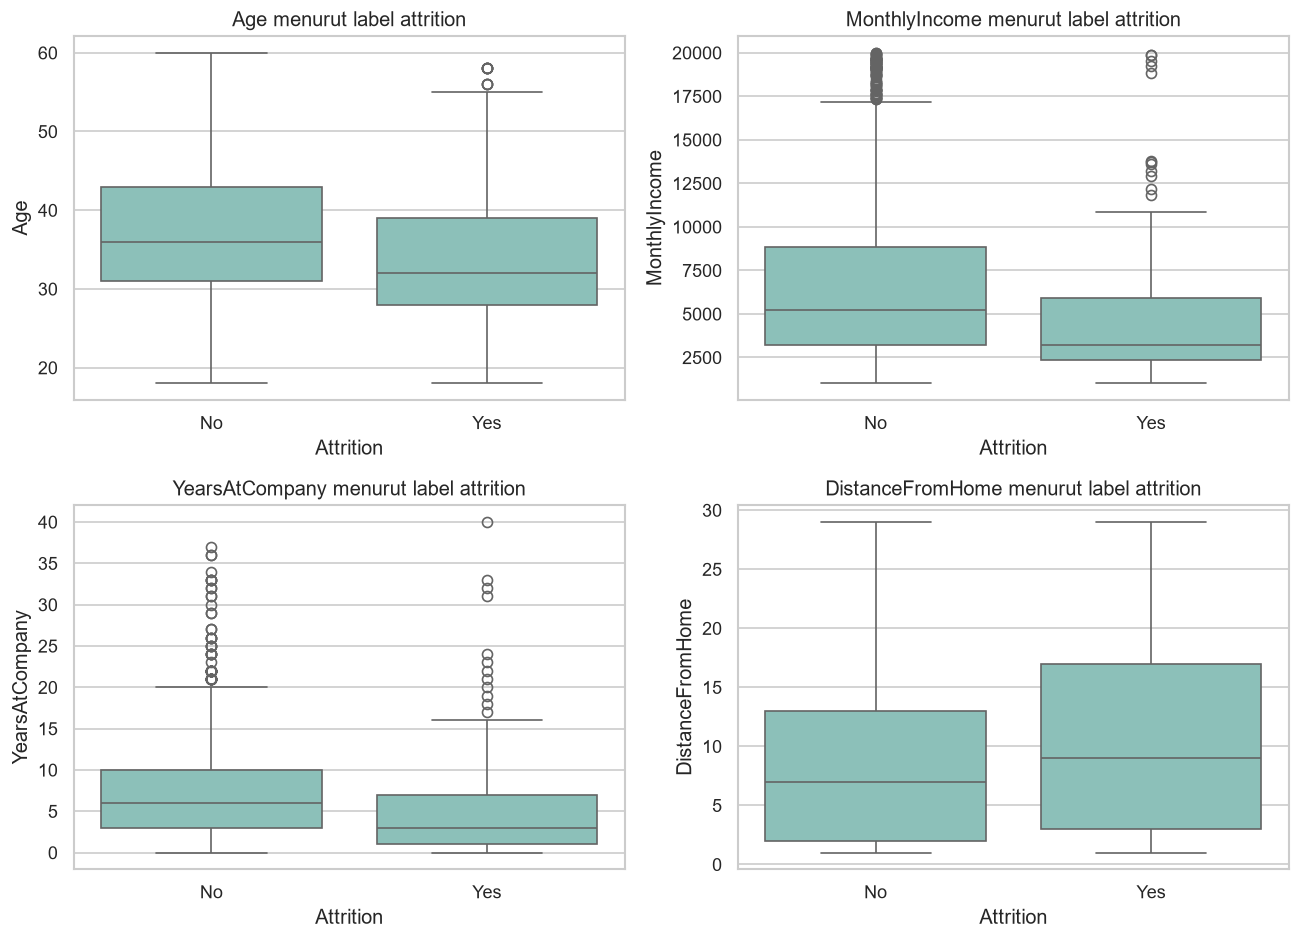

,n,exits,rate_pct,difference_pp,ci_low_pct,ci_high_pct
TenureBand,,,,,,
0–2,342,102,29.82,13.70,25.22,34.88
3–5,434,60,13.82,-2.30,10.89,17.39
6–10,448,55,12.28,-3.85,9.55,15.64
11+,246,20,8.13,-7.99,5.32,12.22


**Pembacaan distribusi:** median MonthlyIncome pada label Yes = 3,202, dibanding No = 5,204 (unit dataset). Median masa kerja Yes = 3 tahun dan No = 6 tahun. Perbedaan ini belum mengendalikan jenjang/peran, sehingga tidak membuktikan bahwa menaikkan income akan mengurangi attrition.

In [7]:
numeric_focus = ['Age','MonthlyIncome','YearsAtCompany','DistanceFromHome']
display(eda.groupby('Attrition')[numeric_focus].agg(['median','mean']).round(2))
fig, axes = plt.subplots(2,2,figsize=(11,8))
for ax,col in zip(axes.flat,numeric_focus):
    sns.boxplot(data=eda,x='Attrition',y=col,order=['No','Yes'],ax=ax,color='#83c9bf')
    ax.set_title(f'{col} menurut label attrition')
plt.tight_layout(); plt.show()
eda['TenureBand'] = pd.cut(eda.YearsAtCompany, bins=[-1,2,5,10,np.inf],
                          labels=['0–2','3–5','6–10','11+'])
tenure_tab = segment_table('TenureBand')
display(tenure_tab.round(2))
medians = eda.groupby('Attrition')[numeric_focus].median()
display(Markdown(f'**Pembacaan distribusi:** median MonthlyIncome pada label Yes = {medians.loc["Yes","MonthlyIncome"]:,.0f}, dibanding No = {medians.loc["No","MonthlyIncome"]:,.0f} (unit dataset). Median masa kerja Yes = {medians.loc["Yes","YearsAtCompany"]:.0f} tahun dan No = {medians.loc["No","YearsAtCompany"]:.0f} tahun. Perbedaan ini belum mengendalikan jenjang/peran, sehingga tidak membuktikan bahwa menaikkan income akan mengurangi attrition.'))

### 05.4 Korelasi dan pemeriksaan konteks
Heatmap Spearman menggambarkan hubungan berpasangan. Masa kerja, jenjang, dan income dapat saling berkaitan; interpretasi bivariate belum mengendalikan confounding. Korelasi dengan target biner hanya ringkasan asosiasi.

Lihat juga lembur **di dalam departemen**, agar perbedaan komposisi kelompok tidak terlewat. Ini masih analisis deskriptif dan tidak membuktikan efek lembur.

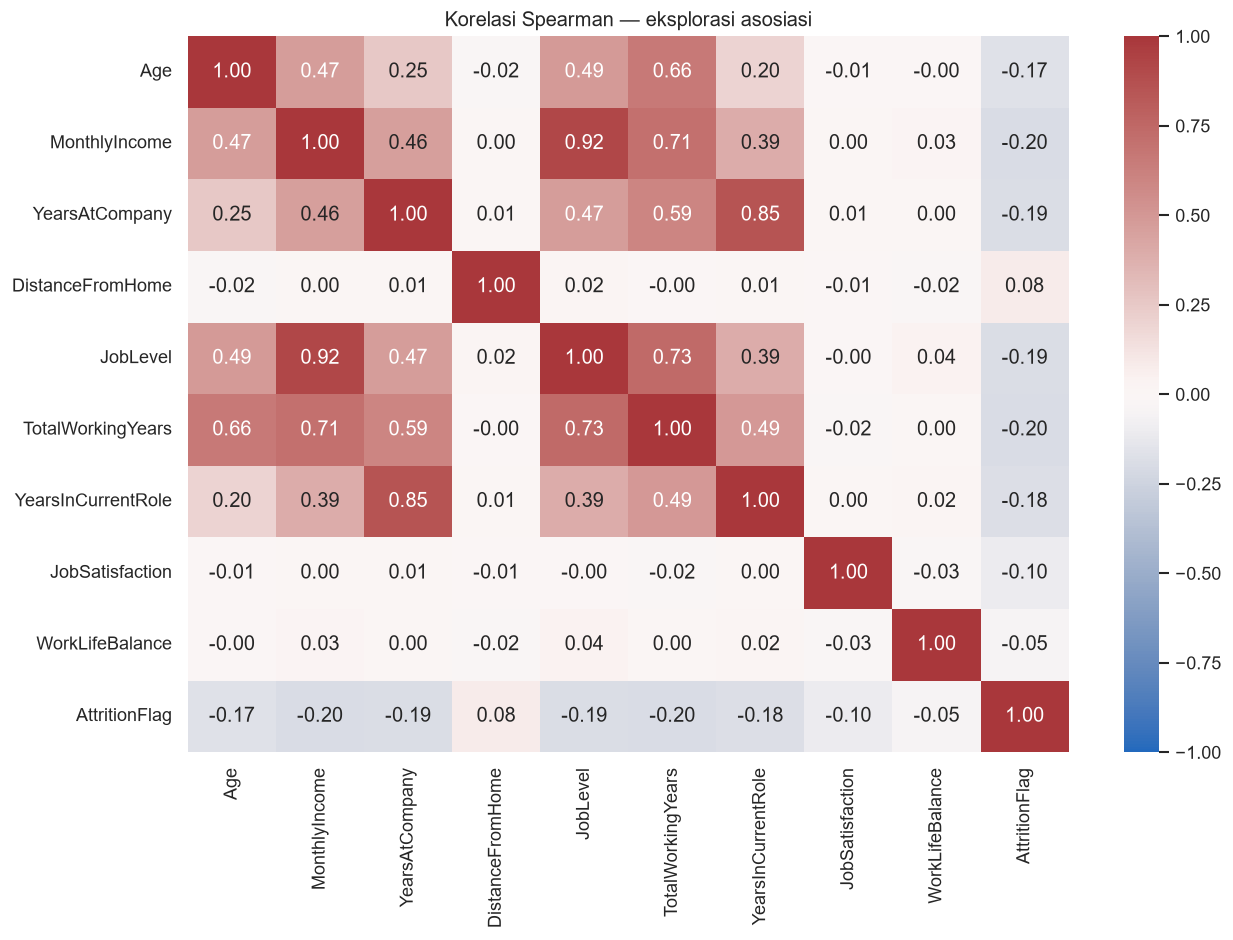

n  exits  rate_pct
Department             OverTime                      
Human Resources        No         46      7     15.22
                       Yes        17      5     29.41
Research & Development No        690     59      8.55
                       Yes       271     74     27.31
Sales                  No        318     44     13.84
                       Yes       128     48     37.50

In [8]:
corr_cols = numeric_focus + ['JobLevel','TotalWorkingYears','YearsInCurrentRole',
                             'JobSatisfaction','WorkLifeBalance','AttritionFlag']
fig, ax = plt.subplots(figsize=(11,8))
sns.heatmap(eda[corr_cols].corr(method='spearman'),annot=True,fmt='.2f',
            cmap='vlag',center=0,vmin=-1,vmax=1,ax=ax)
ax.set_title('Korelasi Spearman — eksplorasi asosiasi')
plt.tight_layout(); plt.show()
context_tab = eda.groupby(['Department','OverTime'],observed=True).AttritionFlag.agg(n='size',exits='sum',rate='mean')
context_tab['rate_pct'] = context_tab.pop('rate')*100
display(context_tab.round(2))

**Cara membaca EDA:** perbedaan proporsi adalah sinyal untuk pertanyaan lanjutan. Kelompok kecil memiliki interval lebar. Perbedaan median income bisa terkait jenjang, usia, atau masa kerja. Tidak ada urutan waktu yang cukup untuk menentukan arah hubungan; hindari kalimat “lembur menyebabkan resign”. Eksplorasi banyak segmen juga meningkatkan peluang menemukan pola kebetulan.

## 06 — SQL dengan SQLite
DataFrame cleaned dimasukkan ke database **in-memory**. Ini latihan SQL yang berjalan di Colab tanpa instalasi layanan database. `CASE WHEN` membuat flag untuk agregasi; `100.0` mencegah integer division. CTE memisahkan pengelompokan masa kerja dari agregasi.

In [9]:
con = sqlite3.connect(':memory:')
df_clean.to_sql('employees',con,index=False,if_exists='replace')
queries = {
 'overall': """SELECT COUNT(*) AS n,
 SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) AS exits,
 100.0*SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)/COUNT(*) AS rate_pct
 FROM employees""",
 'department': """SELECT Department, COUNT(*) AS n,
 SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) AS exits,
 100.0*SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)/COUNT(*) AS rate_pct
 FROM employees GROUP BY Department ORDER BY rate_pct DESC""",
 'overtime_by_department': """SELECT Department, OverTime, COUNT(*) AS n,
 SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) AS exits,
 100.0*SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)/COUNT(*) AS rate_pct
 FROM employees GROUP BY Department,OverTime ORDER BY Department,OverTime""",
 'tenure': """WITH bands AS (
 SELECT *, CASE WHEN YearsAtCompany<=2 THEN '0–2'
 WHEN YearsAtCompany<=5 THEN '3–5' WHEN YearsAtCompany<=10 THEN '6–10'
 ELSE '11+' END AS TenureBand FROM employees)
 SELECT TenureBand,COUNT(*) AS n,
 SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) AS exits,
 100.0*SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)/COUNT(*) AS rate_pct
 FROM bands GROUP BY TenureBand ORDER BY rate_pct DESC"""}
sql_results = {}
for name,query in queries.items():
    display(Markdown(f'### Query: {name}\n```sql\n{query}\n```'))
    sql_results[name] = pd.read_sql_query(query,con)
    display(sql_results[name].round(2))
assert np.isclose(sql_results['overall'].loc[0,'rate_pct'],overall*100)
sql_dept = sql_results['department'].set_index('Department').sort_index()
pd_dept = segments['Department'].sort_index()
assert np.allclose(sql_dept.rate_pct,pd_dept.rate_pct)
assert np.array_equal(sql_dept.n,pd_dept.n)
assert np.array_equal(sql_dept.exits,pd_dept.exits)
sql_tenure = sql_results['tenure'].set_index('TenureBand').sort_index()
pd_tenure = tenure_tab.copy(); pd_tenure.index = pd_tenure.index.astype(str)
pd_tenure = pd_tenure.sort_index()
assert np.allclose(sql_tenure.rate_pct,pd_tenure.rate_pct)
con.close()
print('Cross-check SQL vs pandas: PASS')

Cross-check SQL vs pandas: PASS


### Query: overall
```sql
SELECT COUNT(*) AS n,
 SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) AS exits,
 100.0*SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)/COUNT(*) AS rate_pct
 FROM employees
```

,n,exits,rate_pct
0,1470,237,16.12


### Query: department
```sql
SELECT Department, COUNT(*) AS n,
 SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) AS exits,
 100.0*SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)/COUNT(*) AS rate_pct
 FROM employees GROUP BY Department ORDER BY rate_pct DESC
```

,Department,n,exits,rate_pct
0,Sales,446,92,20.63
1,Human Resources,63,12,19.05
2,Research & Development,961,133,13.84


### Query: overtime_by_department
```sql
SELECT Department, OverTime, COUNT(*) AS n,
 SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) AS exits,
 100.0*SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)/COUNT(*) AS rate_pct
 FROM employees GROUP BY Department,OverTime ORDER BY Department,OverTime
```

,Department,OverTime,n,exits,rate_pct
0,Human Resources,No,46,7,15.22
1,Human Resources,Yes,17,5,29.41
2,Research & Development,No,690,59,8.55
3,Research & Development,Yes,271,74,27.31
4,Sales,No,318,44,13.84
5,Sales,Yes,128,48,37.50


### Query: tenure
```sql
WITH bands AS (
 SELECT *, CASE WHEN YearsAtCompany<=2 THEN '0–2'
 WHEN YearsAtCompany<=5 THEN '3–5' WHEN YearsAtCompany<=10 THEN '6–10'
 ELSE '11+' END AS TenureBand FROM employees)
 SELECT TenureBand,COUNT(*) AS n,
 SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) AS exits,
 100.0*SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)/COUNT(*) AS rate_pct
 FROM bands GROUP BY TenureBand ORDER BY rate_pct DESC
```

,TenureBand,n,exits,rate_pct
0,0–2,342,102,29.82
1,3–5,434,60,13.82
2,6–10,448,55,12.28
3,11+,246,20,8.13


## 07 — Business Insights & Recommendations
Ringkasan berikut dihitung dari data yang dimuat, bukan angka yang diketik manual. Rekomendasi merupakan hipotesis tindakan dan rencana pengukuran; manfaatnya belum terbukti oleh dataset ini.

In [10]:
ot = segments['OverTime']
yes_ot, no_ot = ot.loc['Yes'],ot.loc['No']
top_role = segments['JobRole'].loc[lambda t:t.n>=50].iloc[0]
top_role_name = segments['JobRole'].loc[lambda t:t.n>=50].index[0]
insights_text = f"""### Temuan utama
- **Keseluruhan:** {int(counts['Yes'])}/{len(eda)} observasi berlabel Yes ({overall:.2%}).
- **Lembur:** Yes {yes_ot.rate_pct:.2f}% (n={int(yes_ot.n)}, exits={int(yes_ot.exits)}), dibanding No {no_ot.rate_pct:.2f}% (n={int(no_ot.n)}, exits={int(no_ot.exits)}). Selisih {yes_ot.rate_pct-no_ot.rate_pct:.2f} pp; asosiasi belum mengendalikan semua faktor.
- **Peran pekerjaan:** {top_role_name} memiliki proporsi tertinggi di antara peran dengan n ≥ 50: {top_role.rate_pct:.2f}% (n={int(top_role.n)}). Batas n ini membantu menghindari prioritas hanya karena kelompok sangat kecil.
- **Masa kerja 0–2 tahun:** {tenure_tab.loc['0–2','rate_pct']:.2f}% (n={int(tenure_tab.loc['0–2','n'])}). Bandingkan dengan kelompok lain pada tabel; jangan menyimpulkan efek onboarding tanpa data intervensi.

### Rencana tindak lanjut
| Prioritas | Hipotesis / tindakan | Owner | Pengukuran setelah data riil tersedia |
|---|---|---|---|
| 1 | Audit beban kerja dan jadwal lembur; wawancara sukarela untuk memahami konteks | HRBP + manajer | Jam lembur, kepuasan, proporsi keluar dalam periode yang jelas |
| 2 | Tinjau pengalaman kerja pada peran yang menonjol; bedakan workload, jenjang, dan kompensasi | HR analytics | Perbandingan segmen sebanding, ukuran sampel, interval ketidakpastian |
| 3 | Uji dukungan onboarding/mentoring untuk masa kerja awal | Learning & Development | Retensi cohort 6/12 bulan dan feedback; tetapkan baseline sebelum pilot |

Jika layak, evaluasi pilot dengan kelompok pembanding dan desain yang disepakati; dataset saat ini tidak dapat menghitung ROI atau penurunan resign akibat program. Data demografi digunakan untuk audit representasi, bukan pembatasan kesempatan kerja.
"""
display(Markdown(insights_text))

### Temuan utama
- **Keseluruhan:** 237/1470 observasi berlabel Yes (16.12%).
- **Lembur:** Yes 30.53% (n=416, exits=127), dibanding No 10.44% (n=1054, exits=110). Selisih 20.09 pp; asosiasi belum mengendalikan semua faktor.
- **Peran pekerjaan:** Sales Representative memiliki proporsi tertinggi di antara peran dengan n ≥ 50: 39.76% (n=83). Batas n ini membantu menghindari prioritas hanya karena kelompok sangat kecil.
- **Masa kerja 0–2 tahun:** 29.82% (n=342). Bandingkan dengan kelompok lain pada tabel; jangan menyimpulkan efek onboarding tanpa data intervensi.

### Rencana tindak lanjut
| Prioritas | Hipotesis / tindakan | Owner | Pengukuran setelah data riil tersedia |
|---|---|---|---|
| 1 | Audit beban kerja dan jadwal lembur; wawancara sukarela untuk memahami konteks | HRBP + manajer | Jam lembur, kepuasan, proporsi keluar dalam periode yang jelas |
| 2 | Tinjau pengalaman kerja pada peran yang menonjol; bedakan workload, jenjang, dan kompensasi | HR analytics | Perbandingan segmen sebanding, ukuran sampel, interval ketidakpastian |
| 3 | Uji dukungan onboarding/mentoring untuk masa kerja awal | Learning & Development | Retensi cohort 6/12 bulan dan feedback; tetapkan baseline sebelum pilot |

Jika layak, evaluasi pilot dengan kelompok pembanding dan desain yang disepakati; dataset saat ini tidak dapat menghitung ROI atau penurunan resign akibat program. Data demografi digunakan untuk audit representasi, bukan pembatasan kesempatan kerja.


## 08 — Machine Learning Ringan
### 08.1 Tujuan, fitur, dan pembagian data
Logistic regression memprediksi **label dataset**, bukan probabilitas keluar dalam 6/12 bulan. Tidak ada horizon waktu untuk klaim tersebut.

Gunakan fitur pekerjaan yang dipilih untuk latihan. `Age`, `Gender`, `MaritalStatus`, dan pendidikan tidak masuk model; penghapusan ini **tidak menjamin fairness** karena proxy tetap mungkin ada. ID, target, dan kolom bantu EDA tidak menjadi fitur. Semua fitur harus tersedia **sebelum** keputusan prediksi pada data nyata; waktu pengukurannya belum diverifikasi pada data fiktif ini.

Split stratified: **60% train, 20% validation, 20% test**. Cross-validation hanya pada train; threshold dipilih hanya pada validation; test dipakai setelah pilihan dibekukan. EDA memakai seluruh data sebagai latihan deskriptif, sehingga test ini bukan holdout yang sepenuhnya buta terhadap proses analisis. Untuk klaim generalisasi, diperlukan data baru yang belum dieksplorasi.

In [11]:
feature_cols = ['BusinessTravel','Department','DistanceFromHome','EnvironmentSatisfaction',
 'JobInvolvement','JobLevel','JobRole','JobSatisfaction','MonthlyIncome','NumCompaniesWorked',
 'OverTime','PercentSalaryHike','PerformanceRating','RelationshipSatisfaction','StockOptionLevel',
 'TotalWorkingYears','TrainingTimesLastYear','WorkLifeBalance','YearsAtCompany',
 'YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']
X = df_clean[feature_cols].copy()
y = df_clean.Attrition.map({'No':0,'Yes':1})
X_dev,X_test,y_dev,y_test = train_test_split(X,y,test_size=.2,stratify=y,random_state=SEED)
X_train,X_val,y_train,y_val = train_test_split(X_dev,y_dev,test_size=.25,stratify=y_dev,random_state=SEED)
assert not set(X_train.index)&set(X_val.index)
assert not set(X_dev.index)&set(X_test.index)
display(pd.DataFrame({'n':[len(y_train),len(y_val),len(y_test)],
 'positive_rate':[y_train.mean(),y_val.mean(),y_test.mean()]},index=['train','validation','test']))
ordinal_cols = [c for c in ordinal_ranges if c in feature_cols]
category_cols = sorted(set(X.select_dtypes(include=['object','string']).columns) | set(ordinal_cols))
numeric_cols = [c for c in feature_cols if c not in category_cols]
# One-hot untuk ordinal: tidak memaksakan jarak linear antar tingkat.
preprocessor = ColumnTransformer([
 ('numeric',Pipeline([('imputer',SimpleImputer(strategy='median')),('scale',StandardScaler())]),numeric_cols),
 ('category',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),
                     ('encode',OneHotEncoder(handle_unknown='ignore'))]),category_cols)])
model = Pipeline([('prepare',preprocessor),('model',LogisticRegression(
    max_iter=2000,class_weight='balanced',random_state=SEED))])
baseline = DummyClassifier(strategy='most_frequent')
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)
cv_rows = []
for name,estimator in [('Dummy majority',baseline),('Logistic balanced',model)]:
    result = cross_validate(estimator,X_train,y_train,cv=cv,
                            scoring={'ap':'average_precision','roc_auc':'roc_auc','recall':'recall','f1':'f1'})
    cv_rows.append({'model':name,**{f'{m}_{stat}':float(fn(result['test_'+m]))
        for m in ['ap','roc_auc','recall','f1'] for stat,fn in [('mean',np.mean),('std',np.std)]}})
cv_results = pd.DataFrame(cv_rows)
display(cv_results.round(3))
model.fit(X_train,y_train)
baseline.fit(X_train,y_train)

Out[11]: DummyClassifier(strategy='most_frequent')


,n,positive_rate
train,882,0.162132
validation,294,0.159864
test,294,0.159864


,model,ap_mean,ap_std,roc_auc_mean,roc_auc_std,recall_mean,recall_std,f1_mean,f1_std
0,Dummy majority,0.162,0.003,0.500,0.000,0.000,0.000,0.000,0.000
1,Logistic balanced,0.653,0.024,0.857,0.031,0.812,0.067,0.574,0.027


### 08.2 Pilih threshold pada validation
Threshold 0.5 hanyalah default. Untuk ilustrasi, F2 memberi bobot recall lebih besar daripada precision: melewatkan label Yes dianggap lebih mahal. Ini asumsi latihan, bukan biaya bisnis yang telah dibuktikan. Grid threshold dibatasi 0.10–0.90; pilih F2 tertinggi dan, jika seri, threshold tertinggi. Tidak ada tuning pada test.

`class_weight='balanced'` mengubah penalti training sehingga skor probabilitas belum tentu terkalibrasi. Jangan memperlakukannya sebagai estimasi risiko personal yang akurat.

Threshold dibekukan: 0.27


,threshold,precision,recall,f2
17,0.27,0.299,0.851,0.621
16,0.26,0.292,0.851,0.615
20,0.30,0.309,0.809,0.611
15,0.25,0.286,0.851,0.610
14,0.24,0.284,0.851,0.608
13,0.23,0.280,0.851,0.604
19,0.29,0.297,0.809,0.601
22,0.32,0.308,0.787,0.601
44,0.54,0.405,0.681,0.599
43,0.53,0.405,0.681,0.599


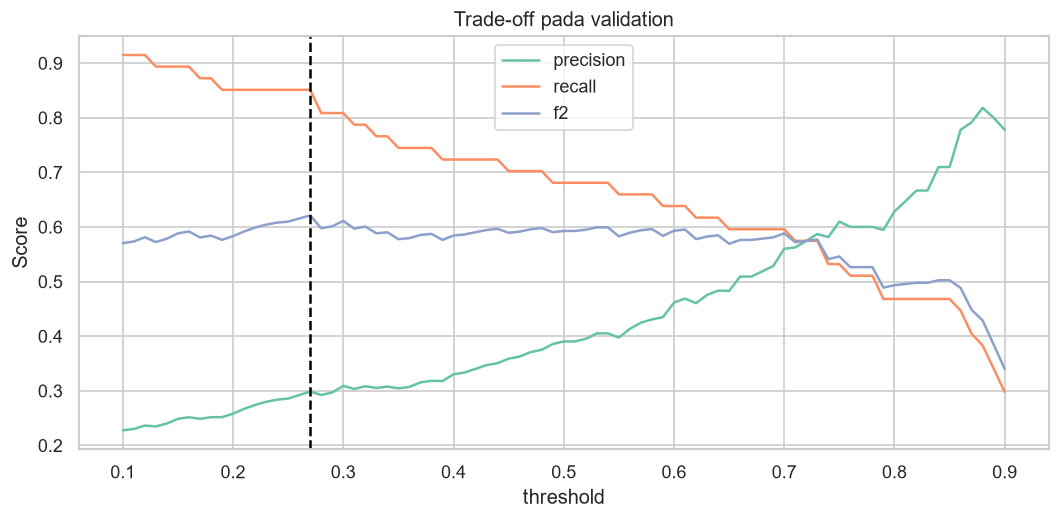

In [12]:
val_scores = model.predict_proba(X_val)[:,1]
threshold_rows = []
for threshold in np.linspace(.1,.9,81):
    pred = (val_scores>=threshold).astype(int)
    threshold_rows.append({'threshold':float(threshold),
        'precision':precision_score(y_val,pred,zero_division=0),
        'recall':recall_score(y_val,pred,zero_division=0),
        'f2':fbeta_score(y_val,pred,beta=2,zero_division=0)})
threshold_table = pd.DataFrame(threshold_rows)
chosen_threshold = float(threshold_table.sort_values(['f2','threshold'],ascending=False).iloc[0].threshold)
display(threshold_table.sort_values(['f2','threshold'],ascending=False).head(10).round(3))
print('Threshold dibekukan:',chosen_threshold)
threshold_table.plot(x='threshold',y=['precision','recall','f2'])
plt.axvline(chosen_threshold,color='black',linestyle='--')
plt.title('Trade-off pada validation'); plt.ylabel('Score'); plt.tight_layout(); plt.show()

### 08.3 Evaluasi test setelah keputusan dibekukan
**Precision:** dari prediksi Yes, berapa yang benar? **Recall:** dari label Yes sebenarnya, berapa yang tertangkap? **F1:** keseimbangan keduanya. **ROC-AUC:** kemampuan meranking dua kelas. **Average precision (AP):** ringkasan precision–recall berbasis ranking; bandingkan dengan prevalensi Yes. AP tidak identik dengan trapezoidal PR-AUC.

False positive = No yang diprediksi Yes; false negative = Yes yang diprediksi No. Test hanya 294 observasi sehingga angka dapat berubah pada split lain. Baris threshold 0.5 adalah pembanding yang telah ditentukan, bukan alternatif untuk dipilih setelah membaca test.

              precision    recall  f1-score   support

          No       0.94      0.63      0.75       247
         Yes       0.29      0.79      0.42        47

    accuracy                           0.65       294
   macro avg       0.61      0.71      0.59       294
weighted avg       0.84      0.65      0.70       294



,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Dummy majority,0.840,0.000,0.000,0.000,0.500,0.160
1,Logistic t=0.5,0.796,0.420,0.723,0.531,0.835,0.622
2,Logistic validation threshold,0.653,0.287,0.787,0.420,0.835,0.622


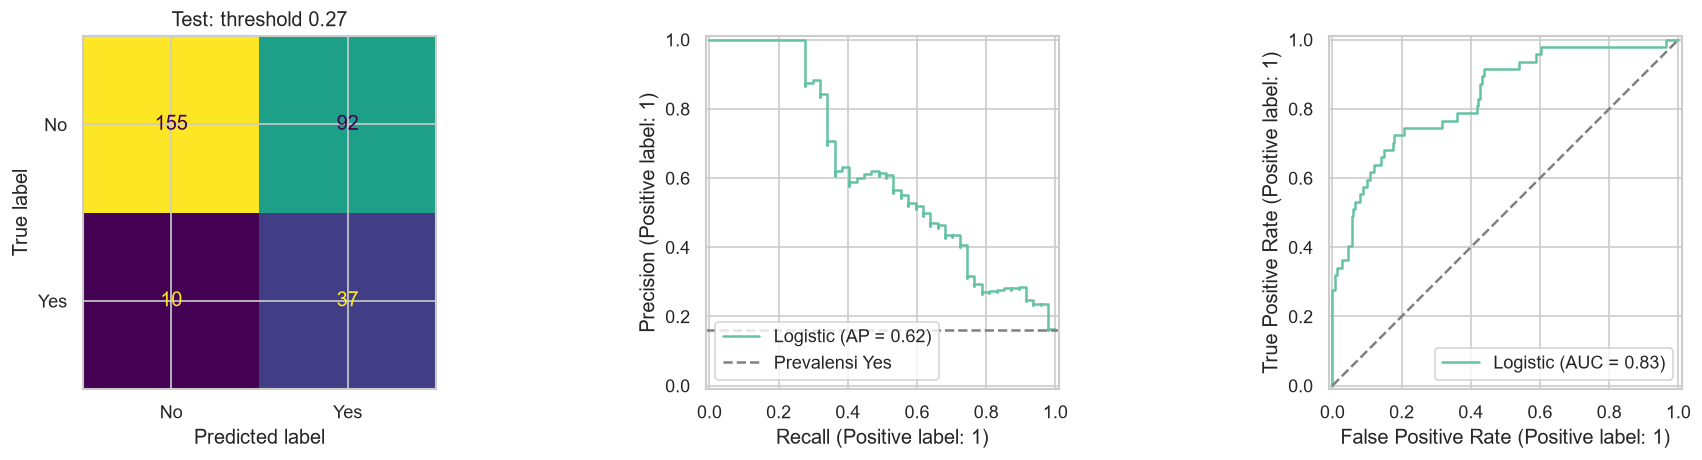

**Hasil test:** threshold validation 0.27, precision 0.287, recall 0.787, F1 0.420, ROC-AUC 0.835, AP 0.622 (prevalensi test 0.160).

Pada threshold terpilih terdapat **92 false positive dan 10 false negative**. Dibanding threshold 0.5, recall berubah dari 0.723 menjadi 0.787, tetapi precision dari 0.420 menjadi 0.287 dan F1 dari 0.531 menjadi 0.420. Jadi prioritas F2 pada validation tidak membuat semua metrik test lebih baik; keputusan operasional memerlukan biaya kesalahan dan kapasitas tindak lanjut yang nyata.

Recall yang lebih tinggi perlu dibaca bersama false positive. AP/ROC-AUC mengukur ranking, bukan dampak program retensi. Model belum layak dipakai untuk keputusan HR individual; threshold dan kalibrasi memerlukan validasi pada data nyata serta tujuan yang disepakati.

In [13]:
test_scores = model.predict_proba(X_test)[:,1]
test_pred = (test_scores>=chosen_threshold).astype(int)
base_scores = baseline.predict_proba(X_test)[:,1]
def metrics_row(name,truth,pred,score):
    return {'model':name,'accuracy':accuracy_score(truth,pred),
      'precision':precision_score(truth,pred,zero_division=0),
      'recall':recall_score(truth,pred,zero_division=0),'f1':f1_score(truth,pred,zero_division=0),
      'roc_auc':roc_auc_score(truth,score),'average_precision':average_precision_score(truth,score)}
test_metrics = pd.DataFrame([
 metrics_row('Dummy majority',y_test,baseline.predict(X_test),base_scores),
 metrics_row('Logistic t=0.5',y_test,(test_scores>=.5).astype(int),test_scores),
 metrics_row('Logistic validation threshold',y_test,test_pred,test_scores)])
display(test_metrics.round(3))
print(classification_report(y_test,test_pred,target_names=['No','Yes'],zero_division=0))
fig,axes = plt.subplots(1,3,figsize=(16,4))
ConfusionMatrixDisplay.from_predictions(y_test,test_pred,display_labels=['No','Yes'],ax=axes[0],colorbar=False)
axes[0].set_title(f'Test: threshold {chosen_threshold:.2f}')
PrecisionRecallDisplay.from_predictions(y_test,test_scores,ax=axes[1],name='Logistic')
axes[1].axhline(y_test.mean(),linestyle='--',color='gray',label='Prevalensi Yes'); axes[1].legend()
RocCurveDisplay.from_predictions(y_test,test_scores,ax=axes[2],name='Logistic')
axes[2].plot([0,1],[0,1],linestyle='--',color='gray')
plt.tight_layout(); plt.show()
row = test_metrics.iloc[-1]
default_row = test_metrics.iloc[1]
false_positive = int(((test_pred == 1) & (y_test.to_numpy() == 0)).sum())
false_negative = int(((test_pred == 0) & (y_test.to_numpy() == 1)).sum())
model_text = f"""**Hasil test:** threshold validation {chosen_threshold:.2f}, precision {row.precision:.3f}, recall {row.recall:.3f}, F1 {row.f1:.3f}, ROC-AUC {row.roc_auc:.3f}, AP {row.average_precision:.3f} (prevalensi test {y_test.mean():.3f}).

Pada threshold terpilih terdapat **{false_positive} false positive dan {false_negative} false negative**. Dibanding threshold 0.5, recall berubah dari {default_row.recall:.3f} menjadi {row.recall:.3f}, tetapi precision dari {default_row.precision:.3f} menjadi {row.precision:.3f} dan F1 dari {default_row.f1:.3f} menjadi {row.f1:.3f}. Jadi prioritas F2 pada validation tidak membuat semua metrik test lebih baik; keputusan operasional memerlukan biaya kesalahan dan kapasitas tindak lanjut yang nyata.

Recall yang lebih tinggi perlu dibaca bersama false positive. AP/ROC-AUC mengukur ranking, bukan dampak program retensi. Model belum layak dipakai untuk keputusan HR individual; threshold dan kalibrasi memerlukan validasi pada data nyata serta tujuan yang disepakati."""
display(Markdown(model_text))

### 08.4 Interpretasi model di validation
Permutation importance mengacak satu fitur dan melihat penurunan AP **di validation**, agar test tidak dipakai lagi untuk memilih fitur. Nilai positif menunjukkan fitur membantu ranking pada sampel ini; nilai negatif berarti pengacakan justru meningkatkan score pada sampel tersebut. Fitur berkorelasi bisa saling menggantikan, sehingga importance bukan besaran efek kausal.

,feature,ap_drop_mean,ap_drop_std
10,OverTime,0.2009,0.0380
15,TotalWorkingYears,0.1539,0.0428
14,StockOptionLevel,0.1111,0.0231
3,EnvironmentSatisfaction,0.0869,0.0267
21,YearsWithCurrManager,0.0834,0.0185
5,JobLevel,0.0790,0.0320
0,BusinessTravel,0.0570,0.0117
6,JobRole,0.0454,0.0198
2,DistanceFromHome,0.0402,0.0246
1,Department,0.0346,0.0209


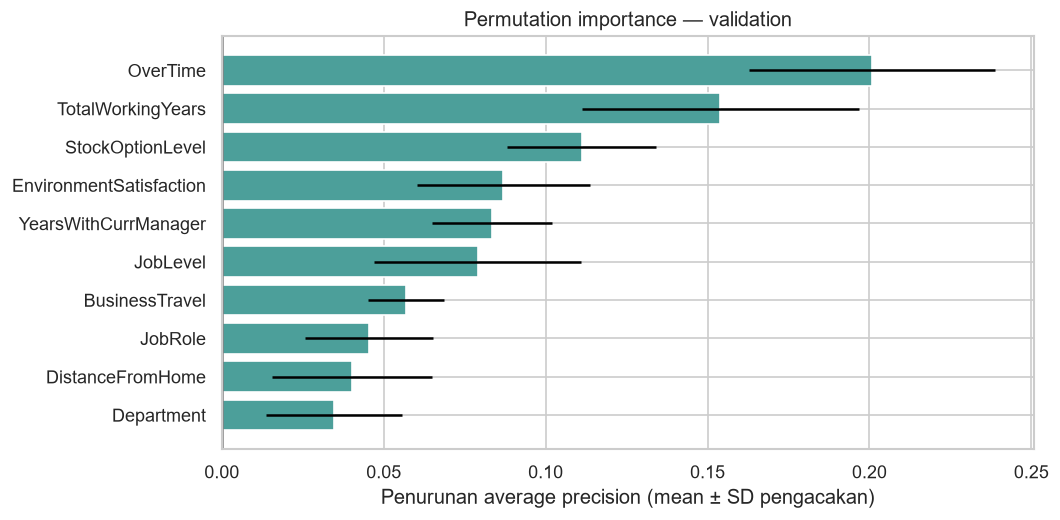

In [14]:
perm = permutation_importance(model,X_val,y_val,scoring='average_precision',n_repeats=10,random_state=SEED)
importance = pd.DataFrame({'feature':feature_cols,'ap_drop_mean':perm.importances_mean,
                           'ap_drop_std':perm.importances_std}).sort_values('ap_drop_mean',ascending=False)
display(importance.round(4))
top = importance.head(10).sort_values('ap_drop_mean')
plt.barh(top.feature,top.ap_drop_mean,xerr=top.ap_drop_std,color='#4c9f9a')
plt.axvline(0,color='gray'); plt.xlabel('Penurunan average precision (mean ± SD pengacakan)')
plt.title('Permutation importance — validation'); plt.tight_layout(); plt.show()

## 09 — Limitations & Conclusion
- Data fiktif dan hanya 1.470 observasi: temuan bukan benchmark industri atau diagnosis tenaga kerja IBM.
- Tidak ada tanggal, horizon prediksi, alasan keluar, atau pemisahan voluntary/involuntary attrition. Tidak dibuat tren bulanan, annual turnover, atau survival analysis.
- Asosiasi dapat dipengaruhi confounding, selection bias, dan banyaknya perbandingan. Interval kelompok hanya ilustrasi ketidakpastian sampling, bukan bukti representasi.
- Model memiliki train/validation/test terpisah dan preprocessing di dalam pipeline. Namun EDA telah melihat data keseluruhan; evaluasi ini latihan internal, bukan validasi eksternal yang benar-benar buta.
- Waktu tersedianya fitur sebelum attrition belum dapat dikonfirmasi. Data operasional baru harus diaudit untuk leakage temporal.
- Tidak mengikutkan demografi tidak menghapus proxy/bias. Belum dilakukan audit fairness, kalibrasi, drift, atau pengujian lintas organisasi.
- Skor klasifikasi bukan kepastian seseorang akan keluar. Gunakan analisis agregat dan dukungan sukarela; jangan menjadikan model dasar sanksi atau pembatasan kesempatan.

**Kesimpulan:** project ini mengubah data mentah menjadi data bersih, membandingkan proporsi kelompok dengan denominator yang jelas, mengecek hasil SQL terhadap pandas, dan menilai model terhadap baseline. Pola lembur/peran/masa kerja merupakan masukan untuk investigasi. Tahap berikutnya membutuhkan data riil bertanggal, definisi outcome, dan evaluasi pilot untuk menguji hipotesis retensi.

## 10 — Persiapan GitHub & Export
Cell berikut menghasilkan cleaned CSV, hasil tabel, query SQL, README draft dengan angka hasil run, metadata versi/checksum, serta ZIP untuk diunduh.

Struktur yang disarankan:
```text
employee-attrition-analysis/
├── README.md
├── notebooks/Employee_Attrition_Analysis_Final.ipynb
├── data/processed/employee_attrition_cleaned.csv
├── reports/ (tabel hasil dan validation_report.json)
├── sql/analysis.sql
└── requirements.txt
```
Sertakan tautan sumber dan tinjau ketentuan dataset sebelum mempublikasikan CSV. Cantumkan bahwa dataset fiktif, jangan mengklaim sebab-akibat atau ROI. Gunakan screenshot grafik yang relevan; jangan memasukkan `.validation_deps`, cache, atau data HR nyata. README draft perlu diisi nama pemilik dan URL repository Anda sebelum publikasi. Notebook ini tidak mempublikasikan repository otomatis.

In [15]:
df_clean.to_csv(OUTPUT_DIR/'employee_attrition_cleaned.csv',index=False)
for col,tab in segments.items(): tab.to_csv(OUTPUT_DIR/f'segment_{col}.csv')
test_metrics.to_csv(OUTPUT_DIR/'model_test_metrics.csv',index=False)
cv_results.to_csv(OUTPUT_DIR/'model_cv_metrics.csv',index=False)
importance.to_csv(OUTPUT_DIR/'model_validation_importance.csv',index=False)
(OUTPUT_DIR/'analysis.sql').write_text('\n\n'.join(f'-- {name}\n{q};' for name,q in queries.items()),encoding='utf-8')
report = {'source_file':source_name,'csv_sha256':data_hash,'raw_shape':list(df.shape),
 'clean_shape':list(df_clean.shape),'missing':int(df_clean.isna().sum().sum()),
 'dropped_columns':drop_columns,'seed':SEED,'split_sizes':{'train':len(y_train),'validation':len(y_val),'test':len(y_test)},
 'selected_threshold':chosen_threshold,'sql_pandas_cross_check':'pass','versions':versions,
 'test_metrics':test_metrics.to_dict(orient='records')}
(OUTPUT_DIR/'validation_report.json').write_text(json.dumps(report,indent=2),encoding='utf-8')
readme = f"""# Employee Attrition Analysis
Portfolio pembelajaran Data Analyst: Python, SQLite, visualisasi, dan logistic regression.

## Tujuan
Memahami proporsi attrition dan asosiasi karakteristik pekerjaan, lalu mengusulkan hipotesis retensi untuk diuji.
Dataset fiktif, bukan tenaga kerja IBM sebenarnya. Hasil tidak membuktikan sebab-akibat.

## Data
Sumber: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
Validasi menggunakan mirror: https://github.com/b1gvini/ibm-hr-analytics-attrition-dataset
Raw: {df.shape[0]} rows × {df.shape[1]} columns; cleaned: {df_clean.shape[0]} × {df_clean.shape[1]}.
Drop EmployeeCount, Over18, StandardHours, EmployeeNumber. SHA256 CSV: `{data_hash}`.

## Cara menjalankan
1. Buka `notebooks/Employee_Attrition_Analysis_Final.ipynb` di Google Colab.
2. Runtime Python → Run all → upload satu CSV/ZIP dari sumber; atau pilih opsi Google Drive pada cell input.
3. Jalankan hingga export. Hasil dapat diunduh dalam ZIP pada cell terakhir.
4. Untuk Jupyter lokal: install requirements, pilih INPUT_MODE='local', isi path relatif CSV.

## Temuan dan rekomendasi
{insights_text}

## Evaluasi model
Split stratified 60/20/20, seed {SEED}, 5-fold CV pada train, threshold dipilih pada validation.
Baseline Dummy majority; preprocessing berada di pipeline. Ordinal di-one-hot.
{model_text}

## Limitations
Tidak ada tanggal/horizon prediksi, data fiktif, sampel kecil, kemungkinan confounding/proxy.
EDA melihat keseluruhan data; test hanya evaluasi internal pembelajaran.
Belum ada validasi eksternal, fairness, kalibrasi atau pengukuran dampak bisnis.

## Struktur
`notebooks/`, `data/processed/`, `reports/`, `sql/`, dan `requirements.txt`.
Pemilik: [isi nama]. Repository: [isi URL]. Tinjau ketentuan sumber sebelum membagikan CSV.
Versi eksekusi: {json.dumps(versions)}.
"""
(OUTPUT_DIR/'README.md').write_text(readme,encoding='utf-8')
(OUTPUT_DIR/'requirements.txt').write_text('pandas>=2.2,<4\nnumpy>=1.26,<3\nmatplotlib>=3.8,<4\nseaborn>=0.13,<0.14\nscikit-learn>=1.4,<2\nipython>=8,<10\n',encoding='utf-8')
zip_path = Path('employee_attrition_outputs.zip')
with zipfile.ZipFile(zip_path,'w',compression=zipfile.ZIP_DEFLATED) as archive:
    for file in sorted(OUTPUT_DIR.iterdir()): archive.write(file,arcname=file.name)
print('Export selesai:',[p.name for p in sorted(OUTPUT_DIR.iterdir())])

Export selesai: ['analysis.sql', 'employee_attrition_cleaned.csv', 'model_cv_metrics.csv', 'model_test_metrics.csv', 'model_validation_importance.csv', 'README.md', 'requirements.txt', 'segment_BusinessTravel.csv', 'segment_Department.csv', 'segment_JobRole.csv', 'segment_JobSatisfaction.csv', 'segment_OverTime.csv', 'segment_WorkLifeBalance.csv', 'validation_report.json']


### Unduh hasil (opsional)
Ubah `DOWNLOAD_RESULTS = True` untuk memulai download ZIP di Colab. Notebook final sendiri dapat disimpan melalui **File → Download → Download .ipynb**. Cell download tidak memengaruhi analisis dan default dimatikan agar Run all tidak memunculkan download otomatis.

In [16]:
DOWNLOAD_RESULTS = False
if DOWNLOAD_RESULTS:
    from google.colab import files
    files.download(str(zip_path))
else:
    print('Aktifkan DOWNLOAD_RESULTS untuk mengunduh hasil di Colab.')

Aktifkan DOWNLOAD_RESULTS untuk mengunduh hasil di Colab.
